# **LSTM & RNN Forecasting**

**Imports**

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error
from keras import Input
from keras.models import Sequential, load_model
from keras.layers import LSTM, SimpleRNN, Dense, Dropout
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.utils import timeseries_dataset_from_array




**Loading Dataset**

In [29]:
df = pd.read_csv("../Datasets/META stocks.csv")
df = df.tail(1000)
# for easier and more dynamic code, save the value column name here
value_column = 'Close'

**Scaling**

In [30]:
scaler = MinMaxScaler()
df[[value_column]] = scaler.fit_transform(df[[value_column]])

df = df.reset_index(drop=True)
df = df.drop("Date", axis=1)
df.index = df.index * 0.1 + 1
df.head()

,Open,High,Low,Close,Adj Close,Volume
1.0,282.529999,283.450012,268.119995,0.336962,271.104401,35346200
1.1,277.179993,286.790009,264.700012,0.323832,263.991577,37758800
1.2,265.299988,266.559998,254.850006,0.311566,257.346954,30389500
1.3,259.519989,264.170013,254.910004,0.318333,261.012939,22914300
1.4,264.000000,268.850006,263.269989,0.327657,266.063660,17320800


**Train/Test Split**

In [31]:
cutoff = int(len(df) * 0.8)

X_train = df.index[0:cutoff]
y_train = df[value_column].iloc[0:cutoff]

X_test = df.index[cutoff:]
y_test = df[value_column].iloc[cutoff:]

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

n_features = 1

train_series = y_train.reshape((len(y_train), n_features))
test_series  = y_test.reshape((len(y_test), n_features))

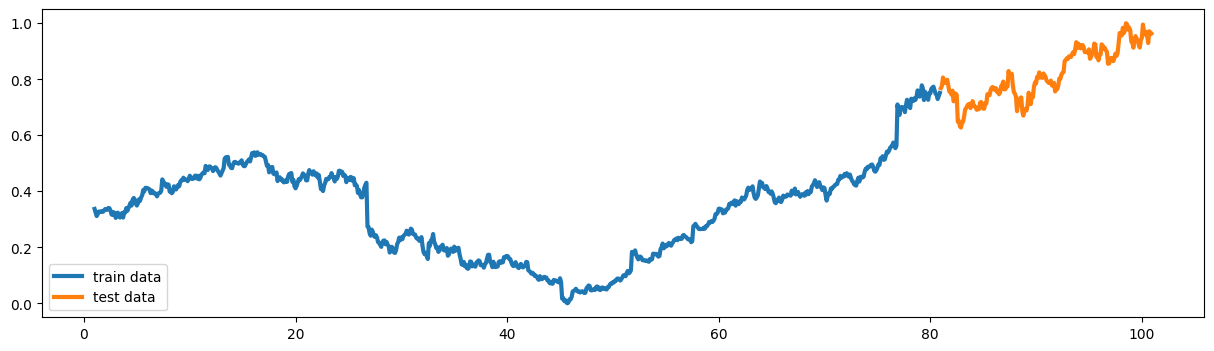

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
ax.plot(X_train,y_train, lw=3, label='train data')
ax.plot(X_test, y_test,  lw=3, label='test data')
ax.legend(loc="lower left")
plt.show()

In [33]:
look_back  = 16
batch_size = 1

train_generator = TimeseriesGenerator(train_series, train_series,
                                      length        = look_back, 
                                      sampling_rate = 1,
                                      stride        = 1,
                                      batch_size    = batch_size)

test_generator = TimeseriesGenerator(test_series, test_series,
                                      length        = look_back, 
                                      sampling_rate = 1,
                                      stride        = 1,
                                      batch_size    = batch_size)

**RNN**

In [34]:

mc = ModelCheckpoint('best_model_rnn.keras', monitor='val_loss', mode='min', save_best_only=True)
callback_list = [mc]

n_neurons = 64

model = Sequential()
model.add(Input(shape=(look_back, n_features)))

model.add(SimpleRNN(n_neurons, activation="relu"))

model.add(Dense(16, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.fit(
    train_generator,
    epochs=100,
    verbose=1,
    validation_data=test_generator,
    callbacks=callback_list
)


Epoch 1/100


c:\Users\stsaa\Desktop\Deep-Learning\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


784/784 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0113 - val_loss: 0.0132
Epoch 2/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0041 - val_loss: 8.0744e-04
Epoch 3/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0028 - val_loss: 0.0057
Epoch 4/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0029 - val_loss: 0.0014
Epoch 5/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0023 - val_loss: 0.0139
Epoch 6/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0021 - val_loss: 7.7282e-04
Epoch 7/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 8/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0022 - val_loss: 0.0246
Epoch 9/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0021 - val_loss: 5.1323e-04
Epoch 10/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0025 - val_loss: 0.0046
Epoch 11/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0023 - val_loss: 0.0079
Epoch 12/100
784/784 ━━━━━━━━━━━━━━━━━━━━

**Training metrics**

<Axes: >

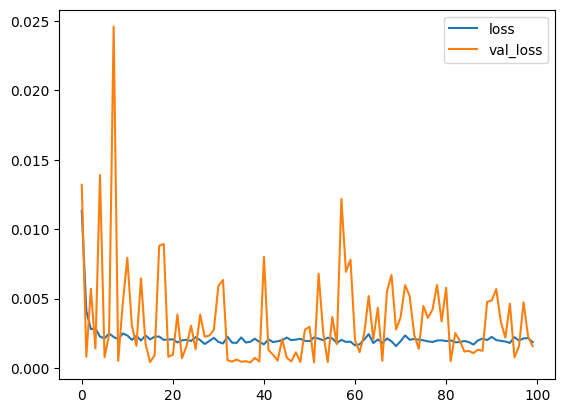

In [35]:
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

**LSTM**

In [36]:
mc = ModelCheckpoint('best_model_lstm.keras', monitor='val_loss', mode='min', save_best_only=True)
callback_list = [mc]

n_neurons  = 64

model = Sequential()
model.add(Input(shape=(look_back, n_features)))
model.add(LSTM(n_neurons, activation="relu"))

model.add(Dense(16, activation="relu"))

model.add(Dropout(0.2))

model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

model.fit(train_generator, epochs=100, verbose=1, validation_data=test_generator, callbacks=callback_list)

Epoch 1/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0107 - val_loss: 0.0089
Epoch 2/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0044 - val_loss: 0.0035
Epoch 3/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0038 - val_loss: 0.0058
Epoch 4/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 - val_loss: 0.0064
Epoch 5/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0039 - val_loss: 0.0040
Epoch 6/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0035 - val_loss: 8.3158e-04
Epoch 7/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - val_loss: 0.0174
Epoch 8/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0032 - val_loss: 0.0025
Epoch 9/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0031 - val_loss: 0.0018
Epoch 10/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0029 - val_loss: 0.0031
Epoch 11/100
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 - val_loss: 5.6037e-04
Epoch 12/100
784/784 ━━━━━━━━━━━━

**Training metrics**

<Axes: >

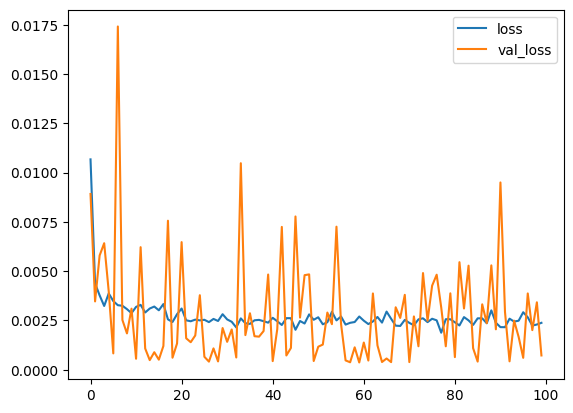

In [37]:
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

**Loading Models**

In [38]:
from keras.models import load_model

lstm_model = load_model("best_model_lstm.keras")
rnn_model  = load_model("best_model_rnn.keras")


**TensorFlow evaluation metrics**

In [39]:
result = model.evaluate(train_generator)
print(f"Training loss: {result}")

result = model.evaluate(test_generator)
print(f"Testing loss: {result}")

784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 641us/step - loss: 2.9610e-04
Training loss: 0.00029610423371195793
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - loss: 7.2728e-04
Testing loss: 0.0007272849325090647


**Test Predictions**

In [40]:
lstm_predictions = lstm_model.predict(test_generator)
rnn_predictions  = rnn_model.predict(test_generator)
actual_y_test = np.array([y for x, y in test_generator]).reshape(-1, 1)

184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step


**Conventional regression metrics + MAPE**

In [41]:
from sklearn import metrics
from sklearn.metrics import mean_absolute_percentage_error

def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")

    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print("MAPE (mean average precision error):")
    print(round(mape, 2), "%")

    print("\nMAE:")
    print(round(metrics.mean_absolute_error(y_true, y_pred), 4))

    print("\nMSE:")
    print(round(metrics.mean_squared_error(y_true, y_pred), 6))

    print("\nRMSE:")
    print(round(np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 6))

    print("\nR-squared:")
    print(round(metrics.r2_score(y_true, y_pred), 4))

evaluate_model("LSTM", actual_y_test, lstm_predictions)
evaluate_model("RNN", actual_y_test, rnn_predictions)



LSTM
MAPE (mean average precision error):
1.71 %

MAE:
0.0138

MSE:
0.000371

RMSE:
0.019265

R-squared:
0.9602

RNN
MAPE (mean average precision error):
1.74 %

MAE:
0.0141

MSE:
0.000397

RMSE:
0.019928

R-squared:
0.9574


The metrics are showing that both models are performing well LSTM being slightly better in metrics

**Prediction Plots**

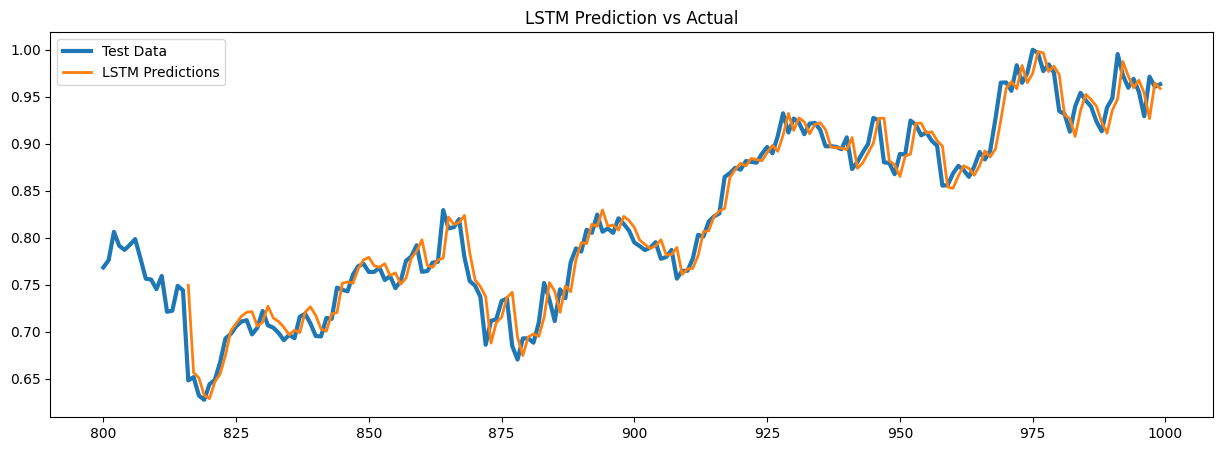

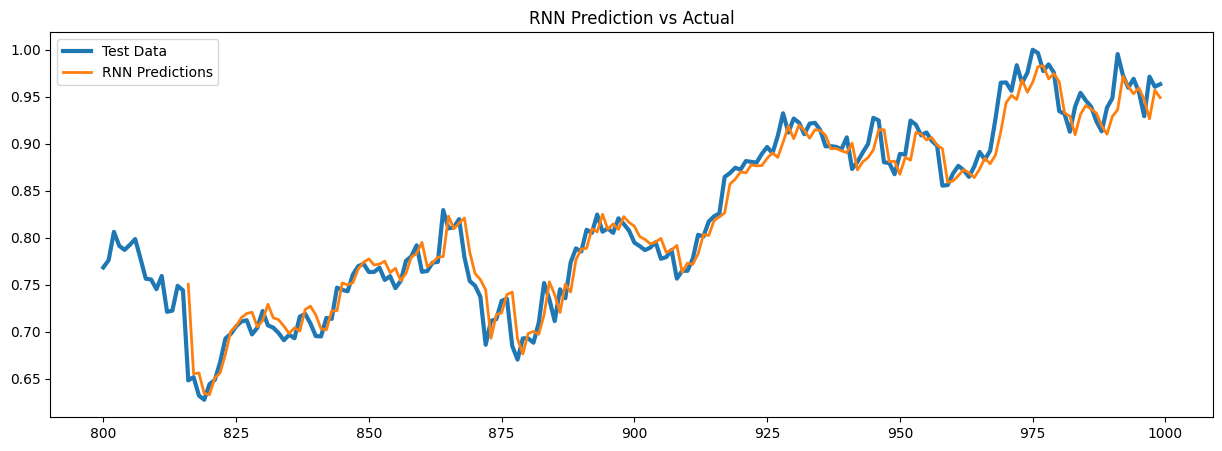

In [42]:
x_train = np.arange(0, len(y_train))
x_test  = np.arange(len(y_train), len(y_train) + len(y_test))
x_pred  = np.arange(len(y_train) + look_back, len(y_train) + len(y_test))

plt.figure(figsize=(15,5))
plt.plot(x_test, y_test, lw=3, label="Test Data")
plt.plot(x_pred, lstm_predictions, lw=2, label="LSTM Predictions")
plt.legend()
plt.title("LSTM Prediction vs Actual")
plt.show()

plt.figure(figsize=(15,5))
plt.plot(x_test, y_test, lw=3, label="Test Data")
plt.plot(x_pred, rnn_predictions, lw=2, label="RNN Predictions")
plt.legend()
plt.title("RNN Prediction vs Actual")
plt.show()


**Summary**

LSTM and RNN are both working well in this case and both predictions are following the trends and spikes well on the final 20% as test data and accurately predicting price.